In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

PROCESSED = ROOT / "data" / "processed"
CHARTS = ROOT / "reports" / "charts"

funds = pd.read_csv(PROCESSED / "clean_fund_master.csv")
nav = pd.read_csv(PROCESSED / "clean_nav.csv")
benchmark = pd.read_csv(PROCESSED / "clean_benchmark.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [ ]:
#Compute daily returns

nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (nav.groupby("amfi_code")["nav"].pct_change())

nav.head()
nav.to_csv(PROCESSED / "returns_computed.csv",index=False)

In [ ]:
#annualized returns
annual_returns = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) == 0:
        continue

    ann_return = ((1 + returns).prod() **(252 / len(returns))- 1)

    annual_returns.append(
        [code, ann_return]
    )

annual_returns = pd.DataFrame(
    annual_returns,
    columns=[
        "amfi_code",
        "annual_return"
    ]
)

In [ ]:
#CAGR
def cagr(nav_series, years):

    trading_days = years * 252

    if len(nav_series) < trading_days:
        return np.nan

    start_nav = nav_series.iloc[-trading_days]
    end_nav = nav_series.iloc[-1]

    return ((end_nav / start_nav)** (1 / years)- 1)
cagr_data = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    values = group["nav"]

    cagr_data.append([
        code,
        cagr(values,1),
        cagr(values,3),
        cagr(values,5)
    ])

cagr_df = pd.DataFrame(
    cagr_data,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

cagr_df.to_csv(
    PROCESSED / "cagr_report.csv",
    index=False
)

In [ ]:
#Sharpe ratio
RF=0.065

sharpe_results = []

for code, group in nav.groupby("amfi_code"):

    r = group["daily_return"].dropna()

    if len(r) < 30:
        continue

    annual_return = (
        (1+r).prod()
        ** (252/len(r))
        - 1
    )

    annual_vol = (
        r.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - RF
    ) / annual_vol

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)



In [ ]:
#sortino ration
sortino_results = []

for code, group in nav.groupby("amfi_code"):

    r = group["daily_return"].dropna()

    downside = r[r < 0]

    if len(downside) < 5:
        continue

    annual_return = (
        (1+r).prod()
        ** (252/len(r))
        - 1
    )

    downside_std = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        annual_return - RF
    ) / downside_std

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

In [ ]:
#alpha and beta

from scipy.stats import linregress
nifty = benchmark[
    benchmark["index_name"]=="Nifty 100"
].copy()

nifty = nifty.sort_values("date")

nifty["benchmark_return"] = (
    nifty["close_value"]
    .pct_change()
)

#regression
alpha_beta = []

for code, group in nav.groupby("amfi_code"):

    merged = group.merge(
        nifty[
            ["date",
             "benchmark_return"]
        ],
        on="date"
    )

    merged = merged.dropna()

    if len(merged) < 30:
        continue

    slope, intercept, *_ = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = slope
    alpha = intercept * 252

    alpha_beta.append([
        code,
        alpha,
        beta
    ])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.to_csv(
    PROCESSED / "alpha_beta.csv",
    index=False
)



In [ ]:
#Maximum drawdown

drawdowns = []

for code, group in nav.groupby("amfi_code"):

    running_max = (
        group["nav"]
        .cummax()
    )

    dd = (
        group["nav"]
        / running_max
        - 1
    )

    drawdowns.append([
        code,
        dd.min()
    ])

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.to_csv(
    PROCESSED / "max_drawdown.csv",
    index=False
)

In [ ]:
#building fund scrorecard

scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(drawdown_df)
    .merge(
        funds[
            ["amfi_code",
             "expense_ratio_pct"]
        ]
    )
)

scorecard["return_rank"] = (
    scorecard["cagr_3yr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank(ascending=True)
)

scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

#composite score
scorecard["fund_score"] = (
      0.30 * scorecard["return_rank"]
    + 0.25 * scorecard["sharpe_rank"]
    + 0.20 * scorecard["alpha_rank"]
    + 0.15 * scorecard["expense_rank"]
    + 0.10 * scorecard["drawdown_rank"]
)

scorecard["fund_score"] = (
    100 *
    (
        scorecard["fund_score"]
        - scorecard["fund_score"].min()
    )
    /
    (
        scorecard["fund_score"].max()
        - scorecard["fund_score"].min()
    )
)

In [ ]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)
scorecard.to_csv(
    PROCESSED / "fund_scorecard.csv",
    index=False
)

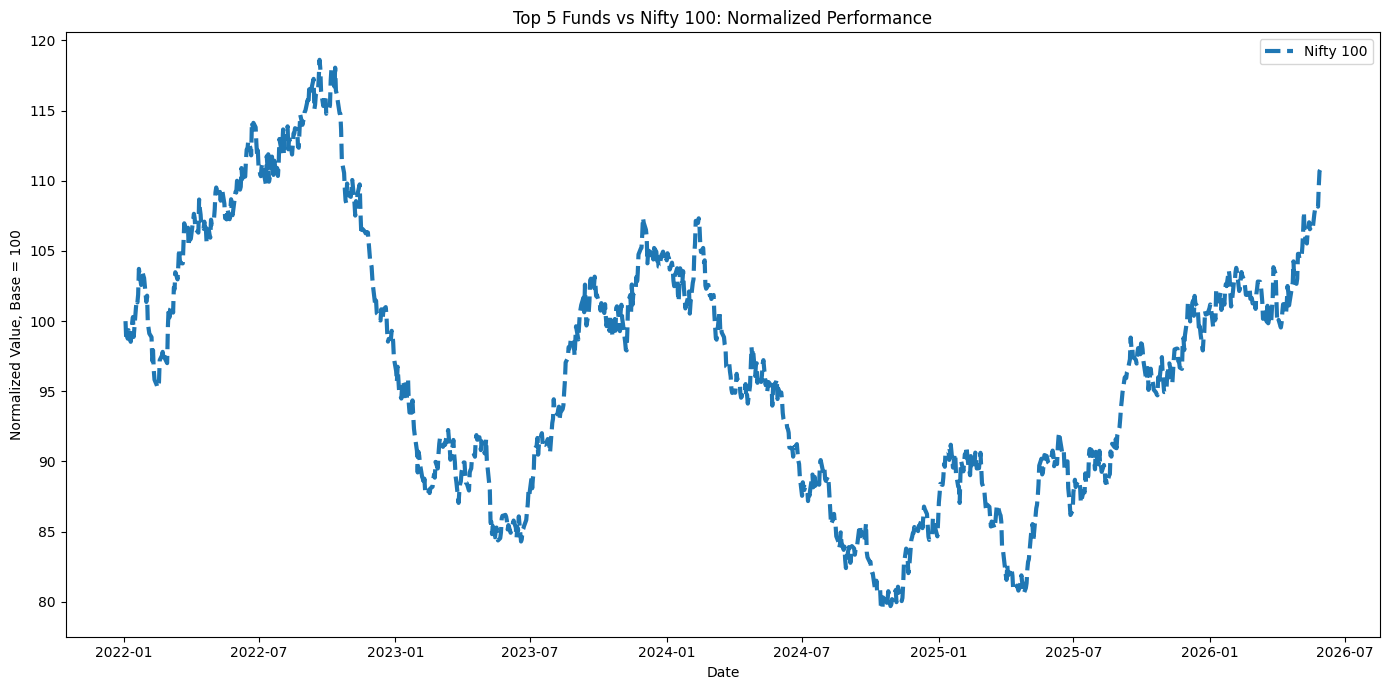

In [ ]:
#comparison check
import matplotlib.pyplot as plt
nav["amfi_code"] = nav["amfi_code"].astype(str)
scorecard["amfi_code"] = scorecard["amfi_code"].astype(str)

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

top5 = scorecard.head(5)["amfi_code"].tolist()

plt.figure(figsize=(14,7))

for code in top5:
    temp = nav[nav["amfi_code"] == code].copy()
    temp = temp.sort_values("date")

    print(code, temp.shape)

    if temp.empty:
        continue

    temp["norm"] = temp["nav"] / temp["nav"].iloc[0] * 100

    plt.plot(
        temp["date"],
        temp["norm"],
        label=f"Fund {code}"
    )

nifty = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty = nifty.sort_values("date")

if not nifty.empty:
    nifty["norm"] = nifty["close_value"] / nifty["close_value"].iloc[0] * 100

    plt.plot(
        nifty["date"],
        nifty["norm"],
        label="Nifty 100",
        linewidth=3,
        linestyle="--"
    )
else:
    print("Nifty 100 not found. Available indices:")
    print(benchmark["index_name"].unique())

plt.legend()
plt.title("Top 5 Funds vs Nifty 100: Normalized Performance")
plt.xlabel("Date")
plt.ylabel("Normalized Value, Base = 100")
plt.tight_layout()
plt.savefig(CHARTS / "benchmark_comparison.png", dpi=300)
plt.show()

In [ ]:
print("CAGR:", cagr_df.shape)
print("Sharpe:", sharpe_df.shape)
print("Alpha Beta:", alpha_beta_df.shape)
print("Drawdown:", drawdown_df.shape)
print("Funds:", funds.shape)